# Experiment 3 — Distortion risk and capital estimation

Distortion-risk diagnostics, capital backtests, contributions and diversification using observed Bloomberg equity losses.

In [1]:
from IPython.display import Image, Markdown, display
from mwc_experiments.reporting import load_result_table, result_figure_path

## Loss processes and dependence

### Observed losses and market stress
Inspect the equally weighted Bloomberg portfolio and the periods identified observably by VIX ≥ 30.

,AAPL_loss,AMZN_loss,JPM_loss,KO_loss,MSFT_loss,NVDA_loss,UNH_loss,WMT_loss,XOM_loss,portfolio_loss,vix
count,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000,3161.000000
mean,-0.000939,-0.000782,-0.000673,-0.000369,-0.000850,-0.001980,-0.000613,-0.000531,-0.000306,-0.000783,18.035233
std,0.017767,0.020625,0.016604,0.011194,0.016981,0.029297,0.018357,0.013371,0.016892,0.011586,6.848079
min,-0.142618,-0.132152,-0.165620,-0.062784,-0.144159,-0.260857,-0.120438,-0.110722,-0.119442,-0.091285,9.140000
25%,-0.009868,-0.011517,-0.008688,-0.005920,-0.009395,-0.016817,-0.008777,-0.006956,-0.008850,-0.006337,13.470000
50%,-0.000995,-0.000987,-0.000818,-0.000493,-0.000834,-0.002365,-0.000837,-0.000663,-0.000319,-0.001178,16.350000
75%,0.007105,0.008943,0.006987,0.004732,0.006977,0.012002,0.007133,0.005639,0.007887,0.004090,20.700000
max,0.137708,0.151397,0.162106,0.101728,0.159453,0.207709,0.253341,0.120766,0.130390,0.127021,82.690000


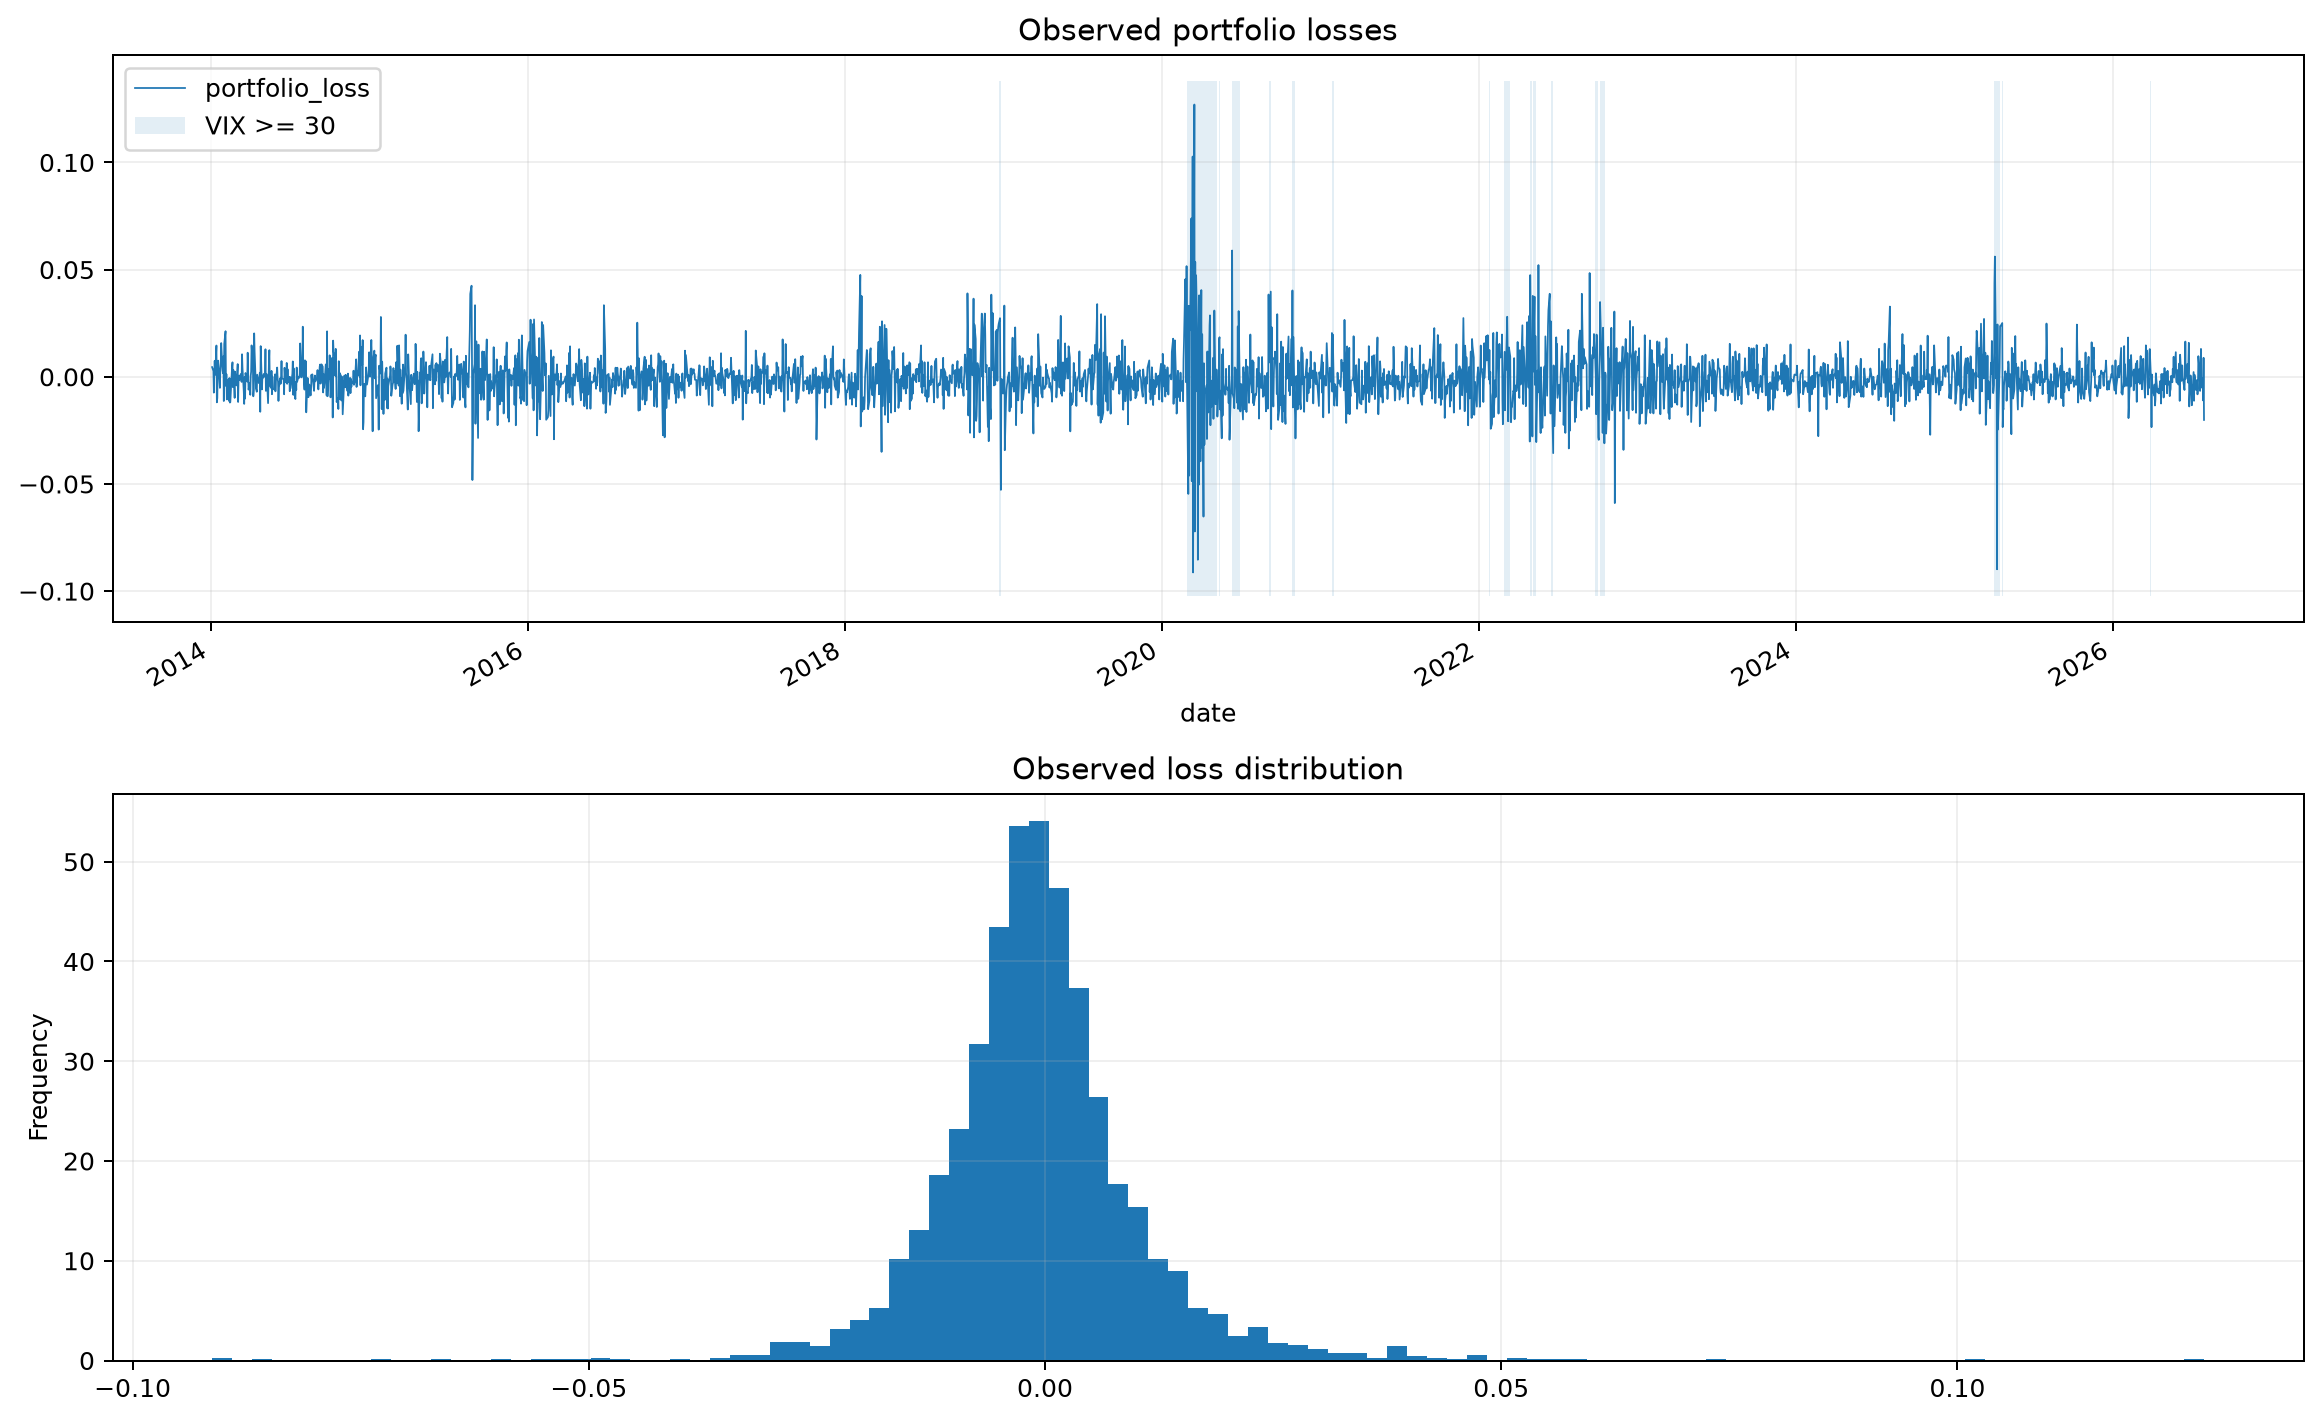

### Stress-dependent correlations
Compare AAPL, JPM and XOM dependence below and above the configured VIX threshold.

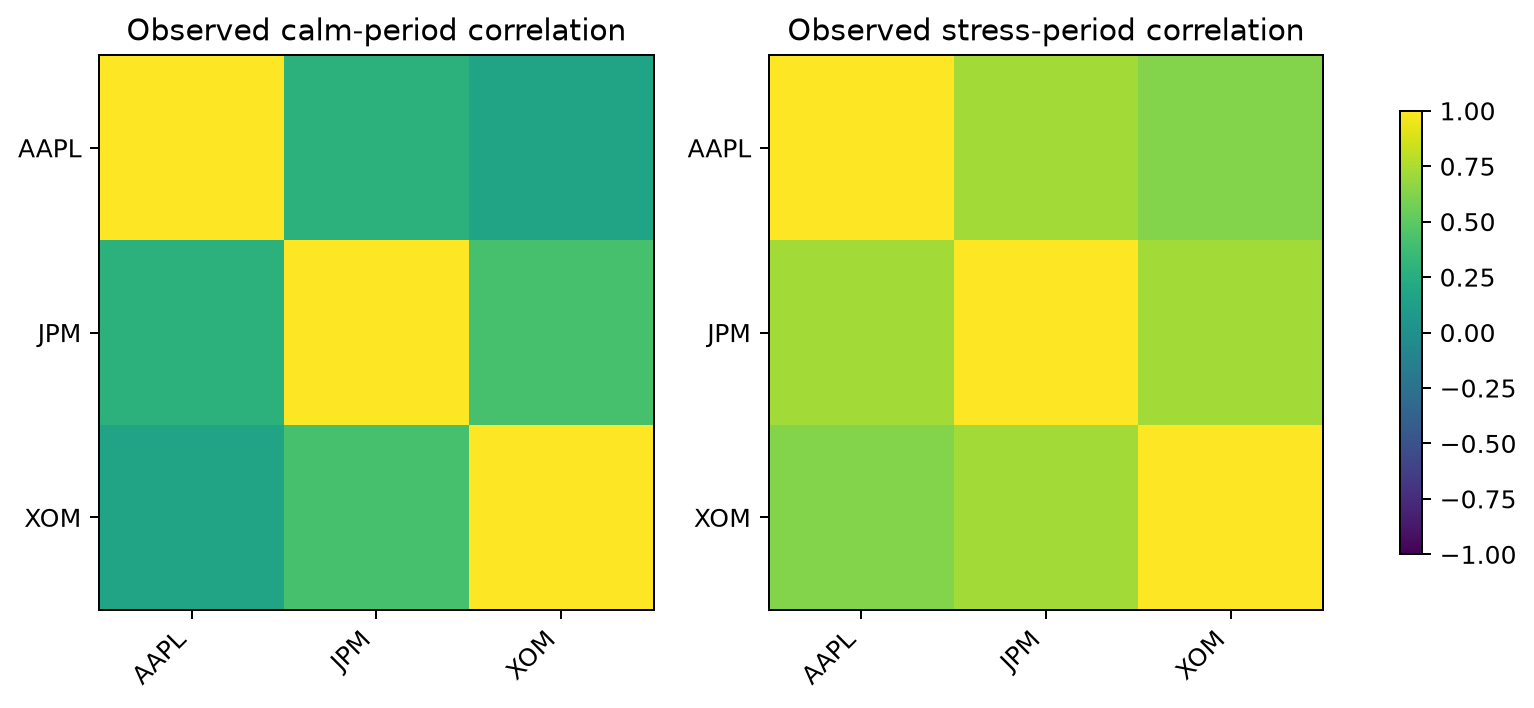

In [2]:
display(Markdown("### Observed losses and market stress\nInspect the equally weighted Bloomberg portfolio and the periods identified observably by VIX ≥ 30."))
display(load_result_table("experiment_3_real_losses.parquet").describe())
display(Image(filename=result_figure_path("experiment_3_loss_process.png")))
display(Markdown("### Stress-dependent correlations\nCompare AAPL, JPM and XOM dependence below and above the configured VIX threshold."))
display(Image(filename=result_figure_path("experiment_3_regime_correlations.png")))

## Static capital and ordered contributions

### Static risk and capital measures
Compare VaR, ES and proportional-hazards capital on the empirical portfolio distribution.

capital
measure              parameter            
Identity / mean loss -           -0.000783
Proportional hazards gamma=0.85   0.001062
                     gamma=0.7    0.003734
                     gamma=0.5    0.010115
Value-at-Risk        alpha=0.95   0.016952
                     alpha=0.975  0.023620
Expected Shortfall   alpha=0.95   0.027987
Value-at-Risk        alpha=0.99   0.033902
Expected Shortfall   alpha=0.975  0.036021
                     alpha=0.99   0.048437

### Ordered ES contributions
Inspect which realized portfolio losses dominate empirical ES 97.5%.

,loss,increment,capacity,contribution
3141,0.038721,0.000015,0.253084,0.000004
3142,0.038916,0.000195,0.240430,0.000047
3143,0.039739,0.000823,0.227776,0.000187
3144,0.040283,0.000544,0.215122,0.000117
3145,0.040458,0.000175,0.202468,0.000035
3146,0.042499,0.002041,0.189813,0.000387
3147,0.043640,0.001141,0.177159,0.000202
3148,0.045483,0.001842,0.164505,0.000303
3149,0.047314,0.001831,0.151851,0.000278
3150,0.047444,0.000130,0.139196,0.000018


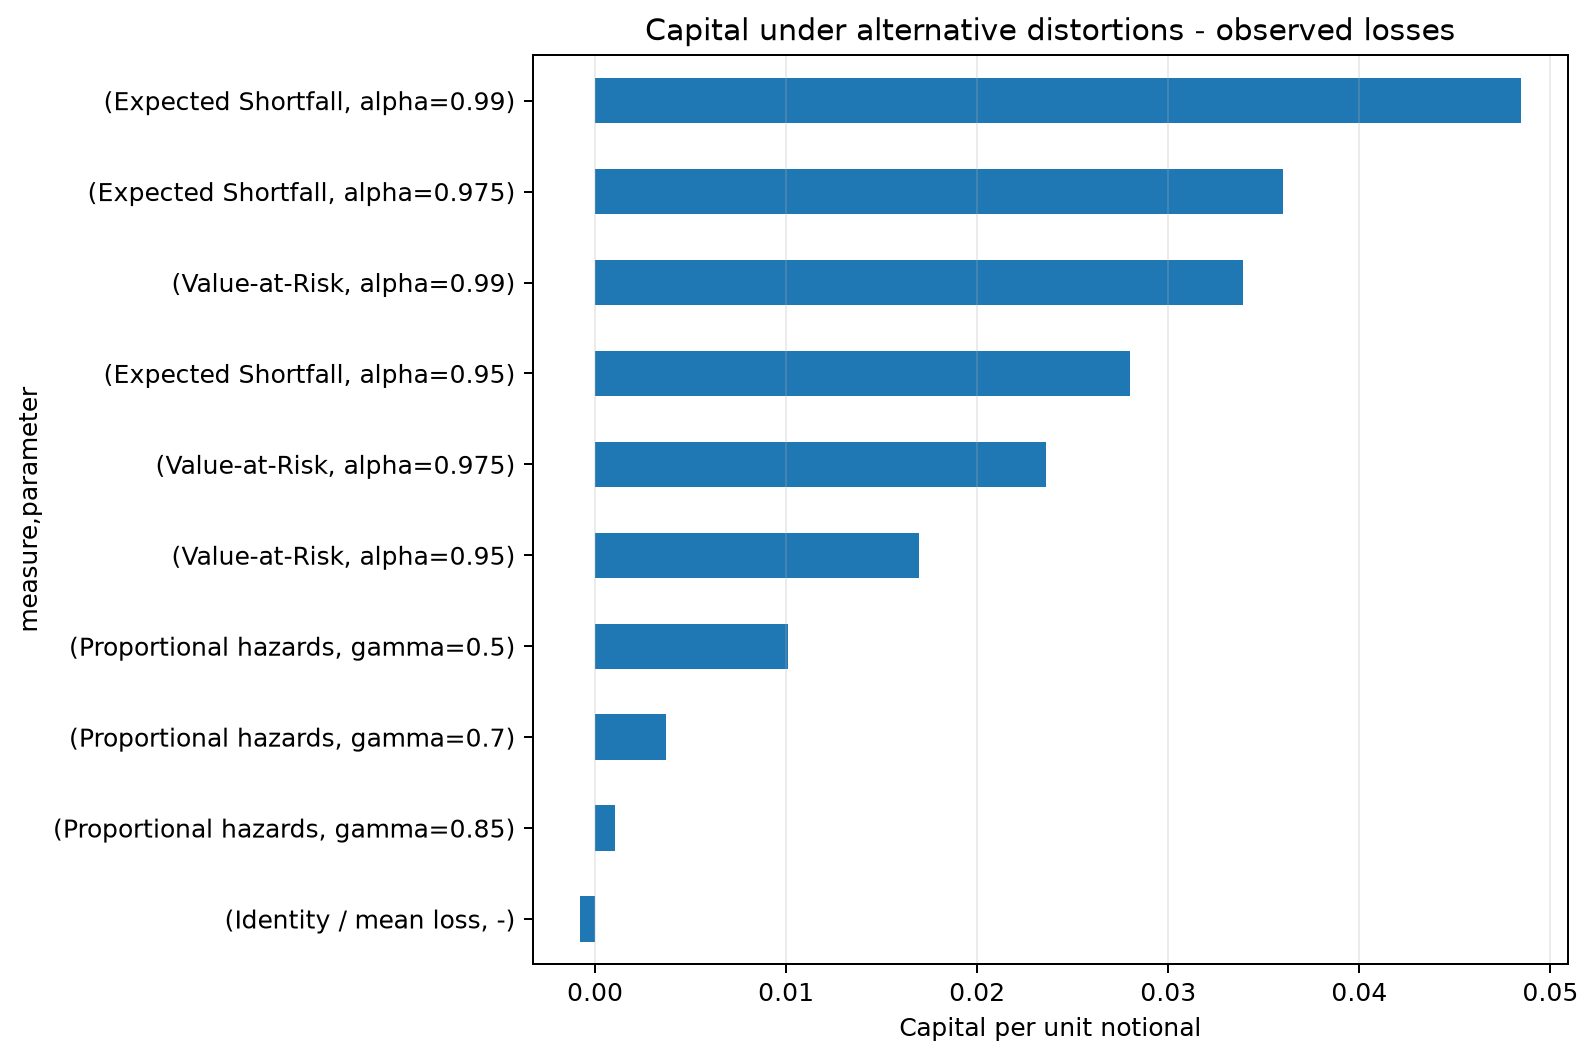

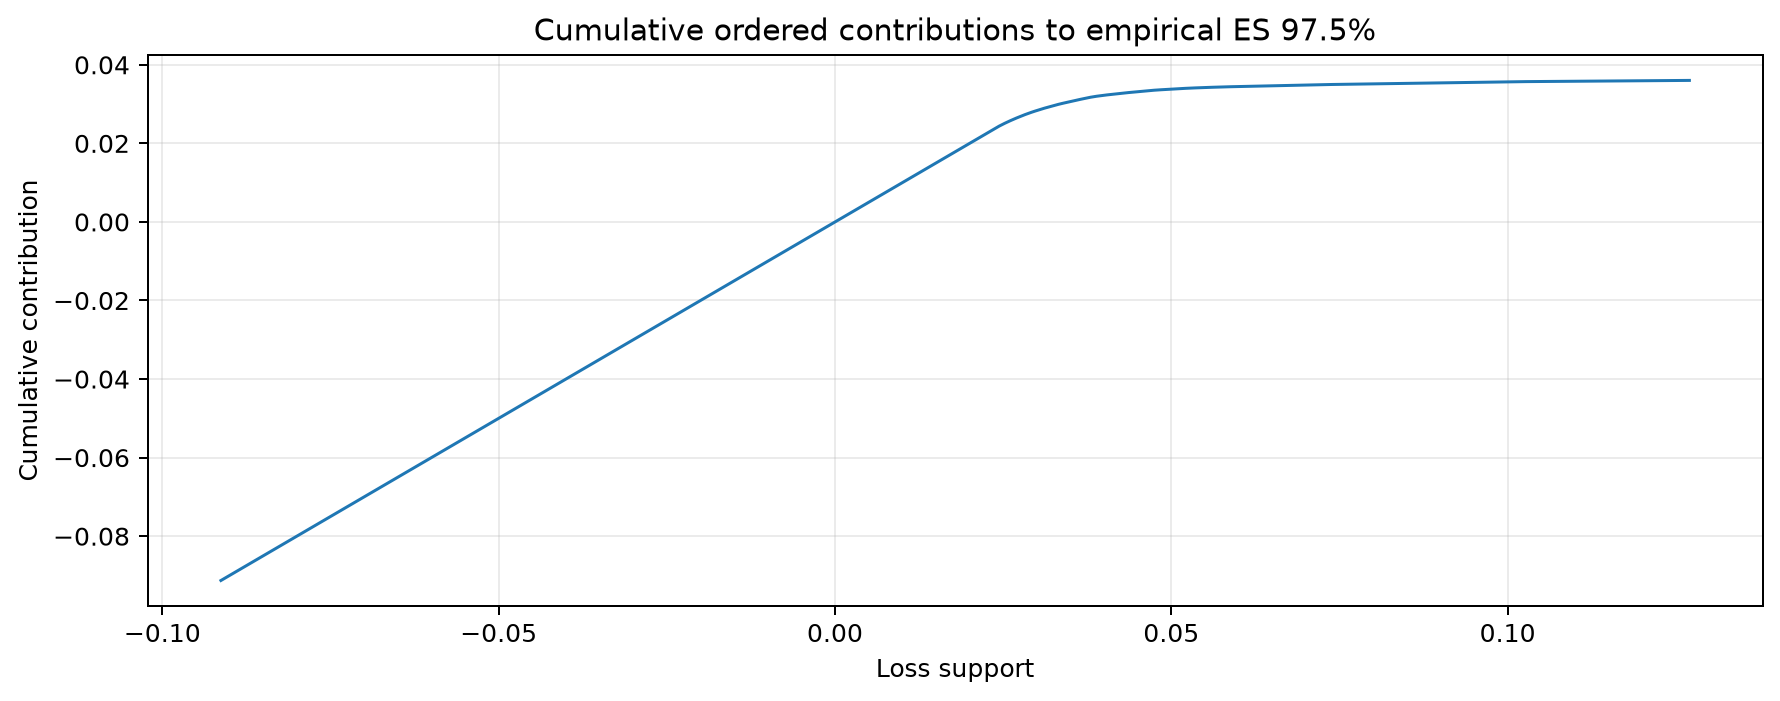

In [3]:
display(Markdown("### Static risk and capital measures\nCompare VaR, ES and proportional-hazards capital on the empirical portfolio distribution."))
display(load_result_table("experiment_3_static_risk_measures.csv", index_col=[0, 1]))
display(Markdown("### Ordered ES contributions\nInspect which realized portfolio losses dominate empirical ES 97.5%."))
display(load_result_table("experiment_3_es_contributions.parquet").tail(20))
display(Image(filename=result_figure_path("experiment_3_static_capital.png")))
display(Image(filename=result_figure_path("experiment_3_es_contributions.png")))

## Rolling capital and backtests

### Rolling capital backtests
Evaluate capital adequacy, exception frequency and instability on realized losses.

n_observations  n_exceedances  exceedance_frequency  \
model         sample                                                        
VaR 99%       all               2909             43              0.014782   
              stress             158             18              0.113924   
ES 97.5%      all               2909             42              0.014438   
              stress             158             18              0.113924   
PH gamma=0.70 all               2909            863              0.296666   
              stress             158             79              0.500000   
PH gamma=0.50 all               2909            475              0.163286   
              stress             158             61              0.386076   

                      average_capital  capital_standard_deviation  \
model         sample                                                
VaR 99%       all            0.031911                    0.015605   
              stress         0.051571                    0.021427   
ES 97.5%      all            0.032248                    0.015577   
              stress         0.052178                    0.021851   
PH gamma=0.70 all            0.003272                    0.001813   
              stress         0.005451                    0.002072   
PH gamma=0.50 all            0.007980                    0.003905   
              stress         0.012886                    0.005080   

                      mean_absolute_capital_change  mean_exceedance  \
model         sample                                                  
VaR 99%       all                         0.000099         0.012093   
              stress                      0.001429         0.022031   
ES 97.5%      all                         0.000097         0.011609   
              stress                      0.001352         0.021240   
PH gamma=0.70 all                         0.000052         0.008119   
              stress                      0.000279         0.022820   
PH gamma=0.50 all                         0.000059         0.008766   
              stress                      0.000452         0.022124   

                      maximum_exceedance  total_exceedance  
model         sample                                        
VaR 99%       all               0.075402          0.519984  
              stress            0.075402          0.396557  
ES 97.5%      all               0.070611          0.487588  
              stress            0.070611          0.382317  
PH gamma=0.70 all               0.121373          7.006551  
              stress            0.121373          1.802747  
PH gamma=0.50 all               0.113158          4.163631  
              stress            0.113158          1.349567

### Coverage and independence
Test whether VaR exceptions match nominal coverage and occur independently over time.

statistic   p_value
model   test                                              
VaR 99% Kupiec unconditional coverage   5.856579  0.015519
        Christoffersen independence    12.832719  0.000341

### Observed stress subgroup
Compare all days with days for which VIX ≥ 30; this label is used for evaluation, not estimation.

average_capital           exceedance_frequency            \
sample                    all    stress                  all    stress   
model                                                                    
ES 97.5%             0.032248  0.052178             0.014438  0.113924   
PH gamma=0.50        0.007980  0.012886             0.163286  0.386076   
PH gamma=0.70        0.003272  0.005451             0.296666  0.500000   
VaR 99%              0.031911  0.051571             0.014782  0.113924   

              mean_exceedance            
sample                    all    stress  
model                                    
ES 97.5%             0.011609  0.021240  
PH gamma=0.50        0.008766  0.022124  
PH gamma=0.70        0.008119  0.022820  
VaR 99%              0.012093  0.022031

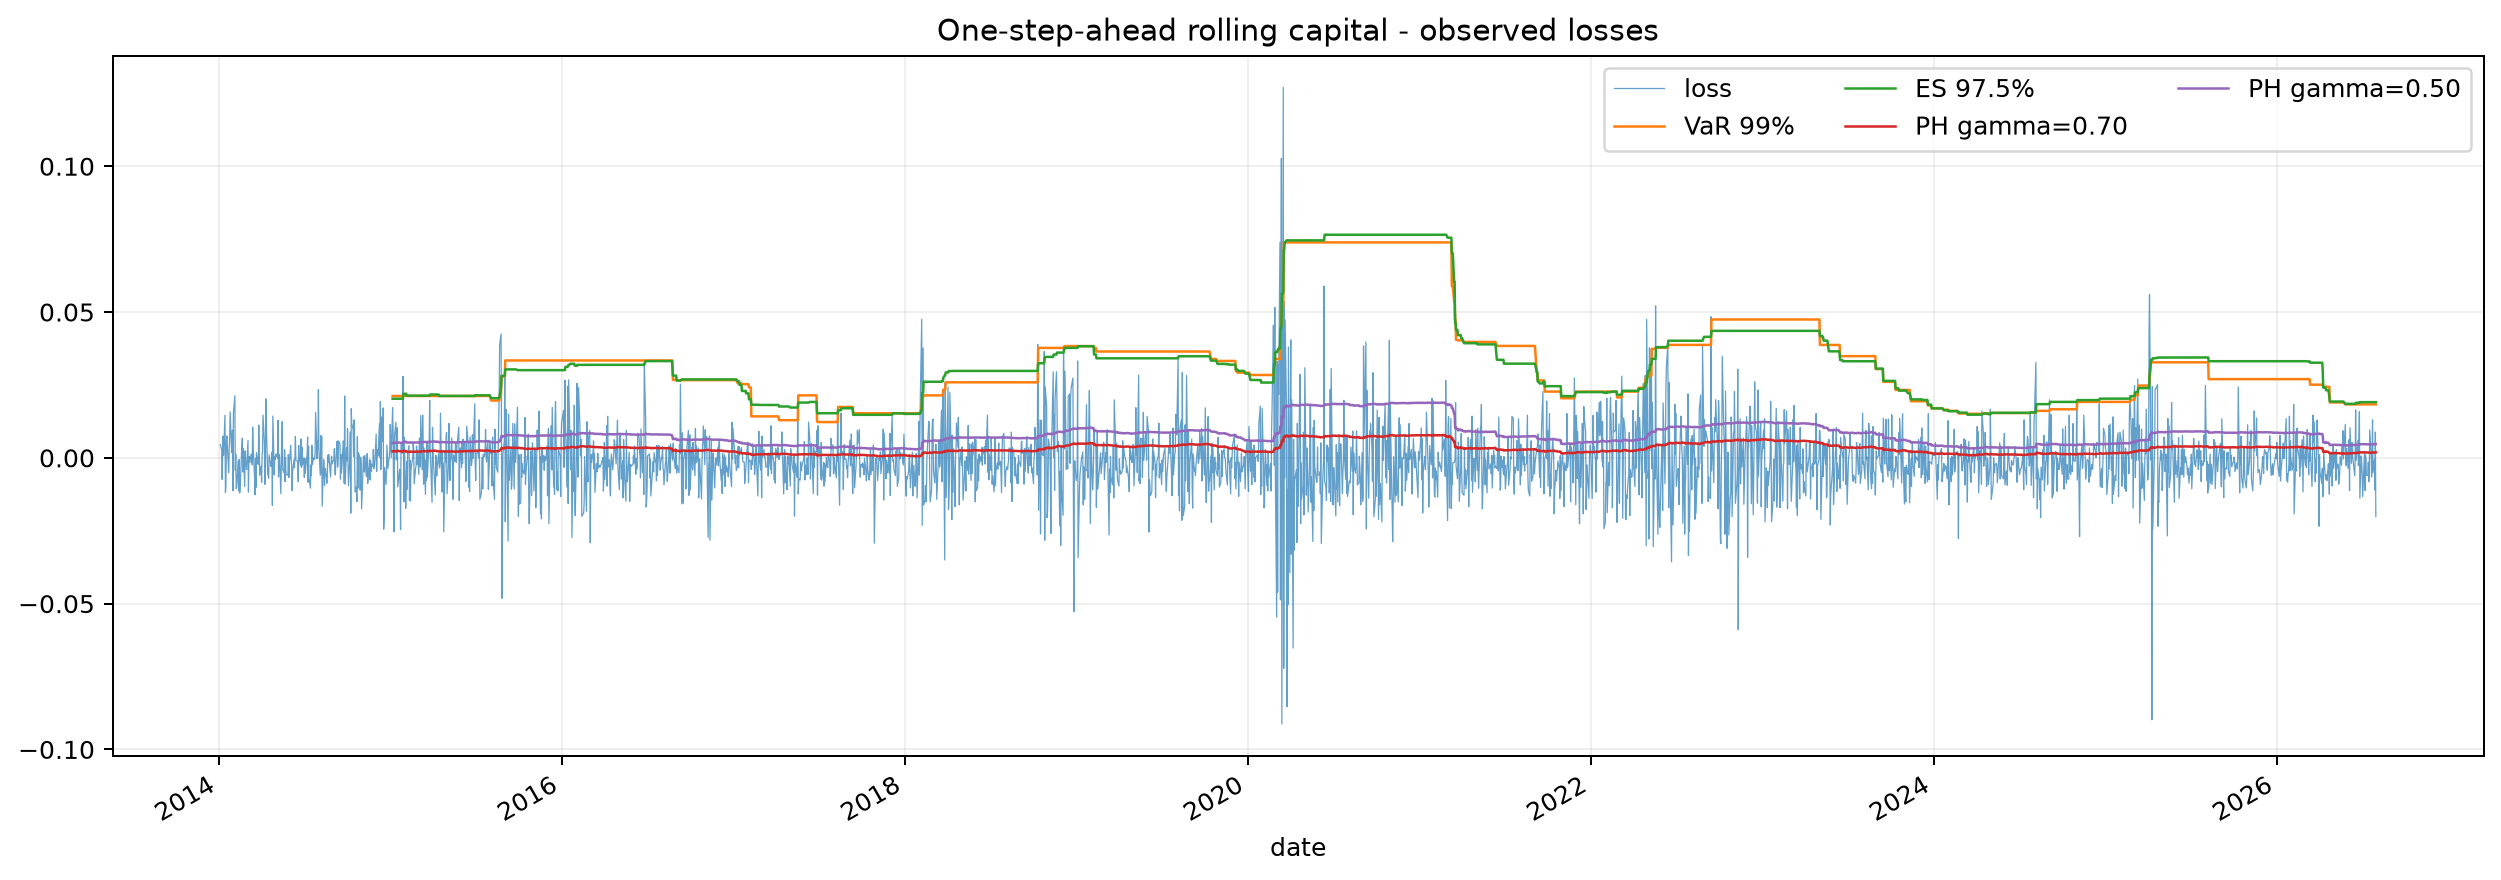

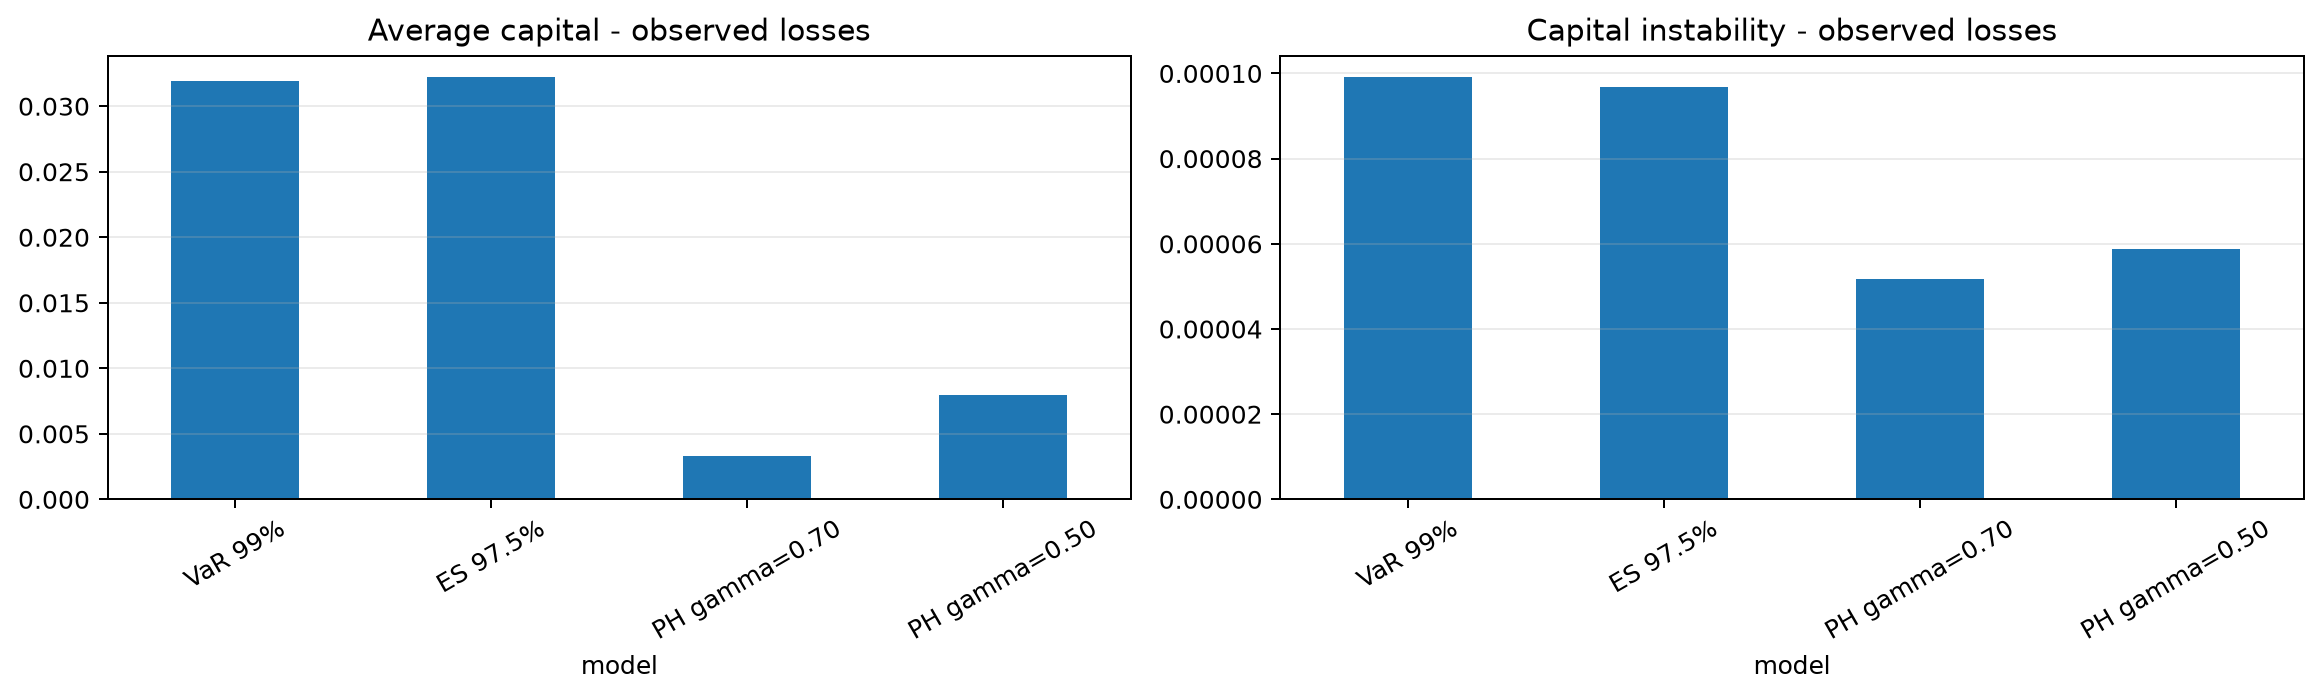

In [4]:
display(Markdown("### Rolling capital backtests\nEvaluate capital adequacy, exception frequency and instability on realized losses."))
display(load_result_table("experiment_3_capital_backtests.csv", index_col=[0, 1]))
display(Markdown("### Coverage and independence\nTest whether VaR exceptions match nominal coverage and occur independently over time."))
display(load_result_table("experiment_3_coverage_tests.csv", index_col=[0, 1]))
display(Markdown("### Observed stress subgroup\nCompare all days with days for which VIX ≥ 30; this label is used for evaluation, not estimation."))
display(load_result_table("experiment_3_stress_comparison.csv", index_col=0, header=[0, 1]))
display(Image(filename=result_figure_path("experiment_3_rolling_capital.png")))
display(Image(filename=result_figure_path("experiment_3_capital_backtests.png")))

## Diversification and numerical axioms

### Observed diversification effects
Use AAPL and JPM as the configured pair to compare stand-alone and combined capital.

,asset A,asset B,rho(A),rho(B),rho(A+B),diversification benefit
measure,,,,,,
VaR 99%,AAPL,JPM,0.049211,0.045131,0.076492,0.017850
ES 97.5%,AAPL,JPM,0.052050,0.049013,0.085770,0.015294
PH gamma=0.70,AAPL,JPM,0.005716,0.005601,0.009450,0.001868
PH gamma=0.50,AAPL,JPM,0.014314,0.014274,0.024806,0.003781


### Numerical axiom checks
Verify the empirical numerical behavior of ES and proportional-hazards measures.

,monotonicity,cash_invariance,positive_homogeneity,subadditivity,convexity,comonotonic_additivity
measure,,,,,,
ES 97.5%,True,True,True,True,True,NaN
PH gamma=0.70,True,True,True,True,True,NaN
PH gamma=1.20,True,True,True,False,False,NaN


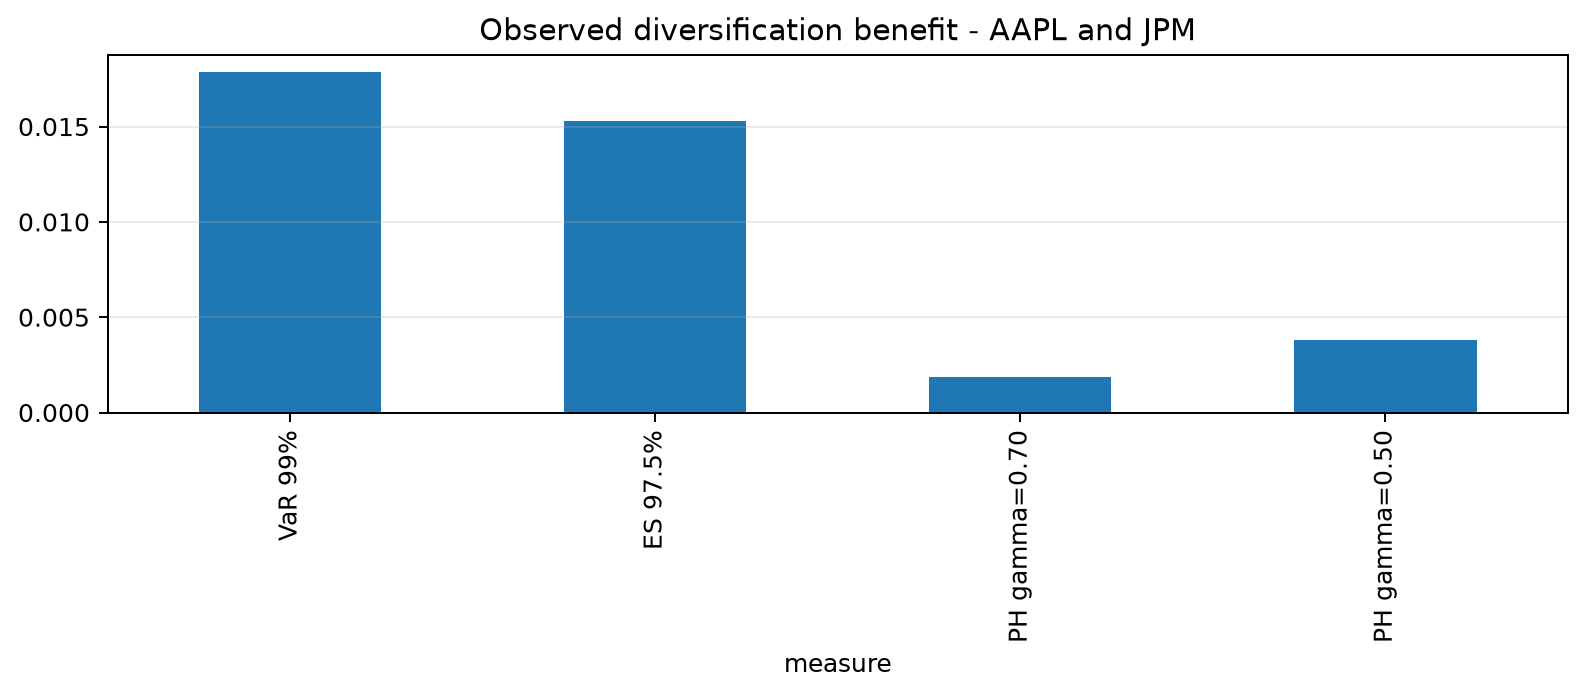

In [5]:
display(Markdown("### Observed diversification effects\nUse AAPL and JPM as the configured pair to compare stand-alone and combined capital."))
display(load_result_table("experiment_3_diversification.csv", index_col=0))
display(Markdown("### Numerical axiom checks\nVerify the empirical numerical behavior of ES and proportional-hazards measures."))
display(load_result_table("experiment_3_axiom_checks.csv", index_col=0))
display(Image(filename=result_figure_path("experiment_3_diversification.png")))